In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat


# Load MATLAB file
mat_data = loadmat('matpower/Hat20_14.mat')
# Access a variable inside the .mat file
H = mat_data['H']



def read_excel_power(file_path= "", id1= 0, id2= 1):
    pfData = pd.read_excel(file_path, engine='openpyxl', sheet_name=id1, parse_dates=['Timestamp'])
    phaseData = pd.read_excel(file_path, engine='openpyxl', sheet_name=id2, parse_dates=['Timestamp'])
    pfData.set_index('Timestamp', inplace=True)
    phaseData.set_index('Timestamp', inplace=True)
    pfData= pfData.to_numpy(dtype= np.float64)
    phaseData= phaseData.to_numpy(dtype= np.float64)
    
    return pfData, phaseData

attackPfData1, attackPhaseData1= read_excel_power("first round/attack_all.xlsx")
attackPfData2, attackPhaseData2= read_excel_power("second round/fdia_data.xlsx")
# attackPfData3, attackPhaseData3= read_excel_power("fdia_result.xlsx", 0, 1)
# originalPfData3, originlaPhaseData3= read_excel_power("fdia_result.xlsx", 2, 3)
# attackPfData4, _= read_excel_power("round 4/fdia_contingency.xlsx", 0, 0)

(-71.95, 1510.95, 0.22731195814907235, 0.36914672034771995)

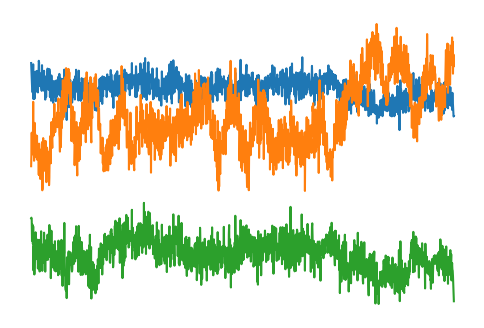

In [30]:
# print(H.shape)
# Hinv= np.linalg.pinv(H)
plt.figure(figsize=(6, 4))
# estAttackState= Hinv.dot(originalPfData3.T)
# estAttackState1= Hinv.dot(originalPfData3.T)
testData= attackPfData2/np.linalg.norm(attackPfData2, 2, axis=1, keepdims= True)
# testData= testData-np.mean(testData, 0, keepdims= True)
plt.plot(testData[:, [1, 2, 3]])
plt.axis('off')
# print(Hinv.shape)
# print(attackPfData3.shape)
# plt.xlabel("Time points")
# plt.ylabel("Estimated state")

In [4]:

temData= attackPfData2[:, :]
# temData= np.random.randn(1000, 20)
print(temData.shape)
U, Sigma, _ = np.linalg.svd(temData.T, full_matrices=True)
print(Sigma[12]/Sigma[0])
print(Sigma)
print(H.shape)
U, Sigma, _ = np.linalg.svd(H, full_matrices=True)
print(Sigma[12]/Sigma[0])

(1440, 20)
0.009538167331278578
[7.65934058e+01 2.73441086e+00 1.34554906e+00 9.22721198e-01
 9.00718777e-01 8.24879410e-01 8.17227098e-01 8.04133910e-01
 7.80791491e-01 7.73408036e-01 7.54678786e-01 7.41232579e-01
 7.30560721e-01 9.37322192e-15 2.71668361e-15 2.63347174e-15
 2.07974715e-15 1.85166293e-15 1.53538307e-15 1.02078679e-15]
(20, 14)
0.08890338719599643


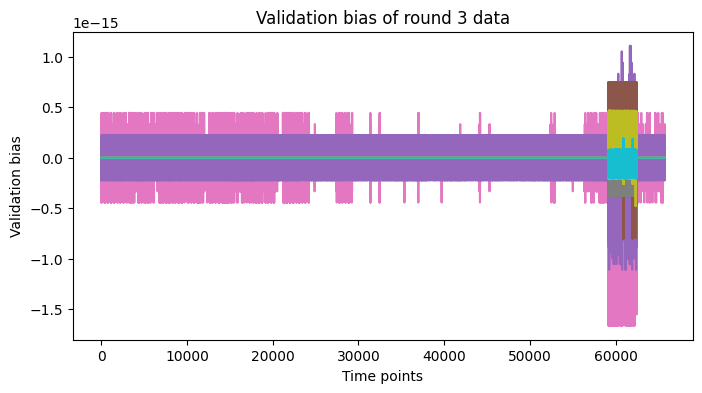

In [6]:
#************* data validation *************#
def validate_data(pfData, phaseData, dataRound= ""):
    bias= H.dot(phaseData.T).T-pfData
    #lengh of bias
    sumBias= np.linalg.norm(bias, 2, 1)
    plt.figure(figsize=(8, 4))
    plt.title(f"Validation bias of {dataRound} data")
    plt.xlabel("Time points")
    plt.ylabel("Validation bias")
    plt.plot(bias)

# validate_data(attackPfData1, attackPhaseData1, "round 1")
# validate_data(attackPfData2, attackPhaseData2, "round 2")
validate_data(attackPfData3, attackPhaseData3, "round 3")
# validate_data(originalPfData3, originlaPhaseData3, "round 3 original")

Text(0, 0.5, 'Pf Data')

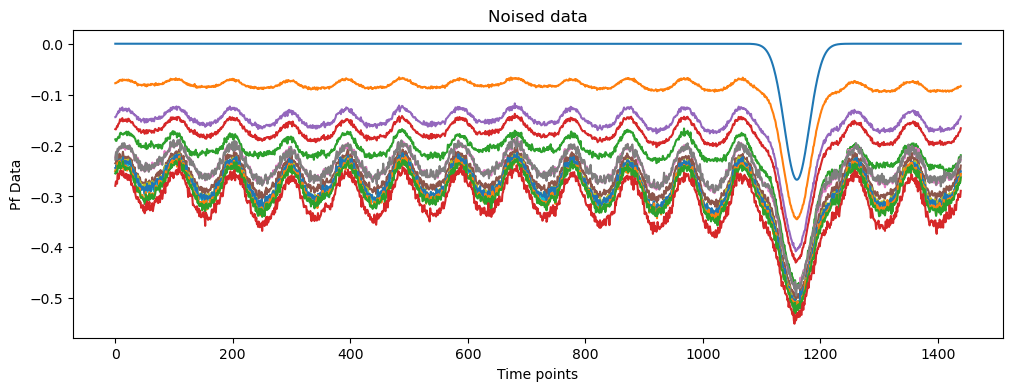

: 

In [ ]:
# add gaussian noise to data

def add_noise_to_data(data, std= 0):
    noisedData= data.copy()
    noisedData+= np.random.rand(data.shape[0], data.shape[1])*std
    return noisedData

noisedOriginalPfData3= add_noise_to_data(attackPfData2, 0.0001)
plt.figure(figsize=(12, 4))
plt.plot(attackPhaseData2)
plt.title(f"Noised data")
plt.xlabel("Time points")
plt.ylabel("Pf Data")

(1440, 14)


Text(0, 0.5, 'PF Data')

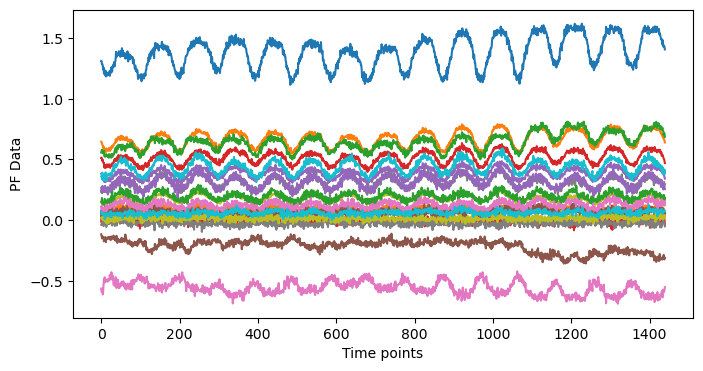

In [28]:
plt.figure(figsize=(8, 4))
plt.plot(attackPfData2)
print(attackPhaseData2.shape)
# plt.plot(attackPhaseData2-attackPhaseData2[:, 0:1])
# plt.title(f"Noised data")
plt.xlabel("Time points")
plt.ylabel("PF Data")

  0%|          | 0/300 [00:00<?, ?it/s]


[4.37471746e-01 2.44757101e-01 1.62948039e-01 1.48513510e-01
 1.33757072e-01 1.31689046e-01 1.29357547e-01 1.27720775e-01
 1.25813348e-01 1.22342558e-01 1.20307108e-01 1.17951815e-01
 2.39043290e-02 5.76600250e-16 4.29345749e-16 3.87626757e-16
 3.51449862e-16 3.00039842e-16 2.89297006e-16 1.70951800e-16]


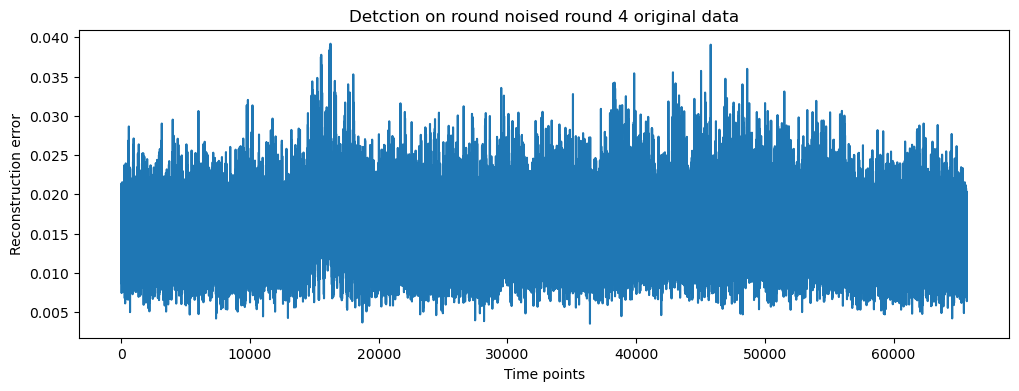

In [35]:
#************* attack detection *************#

def attack_detection_reconstruction_error(trainData, testData, dataRound= ""):
    # normalize data
    trainData= trainData/np.linalg.norm(trainData, 1, axis=1, keepdims= True)
    trainData= trainData-np.mean(trainData, 0, keepdims= True)
    testData= testData/np.linalg.norm(testData, 1, axis=1, keepdims= True)
    testData= testData-np.mean(testData, 0, keepdims= True)
    # Perform SVD
    U, Sigma, _ = np.linalg.svd(trainData.T, full_matrices=True)
    #
    print(Sigma)

    # Select columns of U corresponding to non-zero singular values
    rank= 10
    # Obtian null space
    A = U[:, rank:]
    # perform test
    A_pinv = np.linalg.pinv(A)
    # print(A_pinv.shape)
    ys= A_pinv.dot(testData.T)
    error= A.dot(ys)

    #length of reconstruction error
    sumError= np.linalg.norm(error, 2, 0)

    #Plot reconstruction error
    plt.figure(figsize=(12, 4))
    plt.plot(sumError)
    plt.title(f"Detction on round {dataRound} data")
    plt.xlabel("Time points")
    plt.ylabel("Reconstruction error")
    return sumError

# attack_detection_reconstruction_error(attackPfData1, attackPfData1, "round 1")
# attack_detection_reconstruction_error(attackPfData2, attackPfData2, "round 2")
# attack_detection_reconstruction_error(attackPfData3[0:10000, :], attackPfData3, "round 3") # only train with first 10000 data
# attack_detection_reconstruction_error(originalPfData3[0:10000, :], originalPfData3, "round 3 original") # only train with first 10000 data
from skimage.filters import threshold_li
from sklearn.metrics import precision_score, recall_score
from tqdm import tqdm
# attackStartTime= 59129
# attackEndTime= -3285
# actual_labels = np.zeros(noisedOriginalPfData3.shape[0])
# actual_labels[attackStartTime: attackEndTime]= 1

#0.1 to 0.0001

precisions= []
recalls= []
stds= []
for i in  tqdm(range(300)):
    stdCur= 0.000*i#0, 0.005, 0.01, 0.02, 0.05
    stds.append(stdCur)
    # noisedOriginalPfData3= add_noise_to_data(attackPfData4, stdCur)
    # noisedOriginalPfData3[:, attackStartTime: attackEndTime]= originalPfData3[:, attackStartTime: attackEndTime]
    attackPfData4Cp= attackPfData4.copy()
    attackPfData4Cp[:, 13]= 0
    sumError= attack_detection_reconstruction_error(attackPfData2, attackPfData4Cp, "noised round 4 original") # only train with first 10000 data
    threshold = threshold_li(sumError)
    predicted_labels= sumError>threshold
    # precision = precision_score(actual_labels, predicted_labels)
    # recall= recall_score(actual_labels, predicted_labels)
    # precisions.append(precision)
    # recalls.append(recall)
    break

Text(0.5, 0, 'Std of noise')

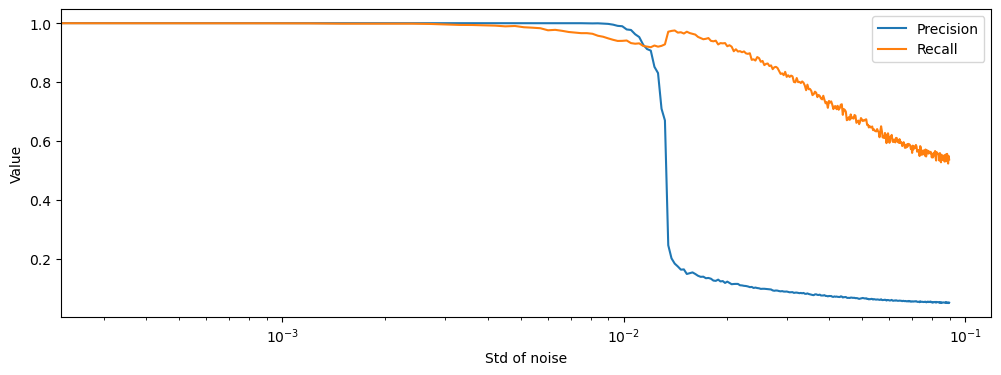

In [27]:
plt.figure(figsize=(12, 4))#point adjusted
plt.plot(stds, precisions, label= "Precision")
plt.plot(stds, recalls, label= "Recall")
plt.legend()
plt.xscale("log")
plt.ylabel("Value")
plt.xlabel("Std of noise")

[0.00225758 0.00225692 0.00222134 0.00220496 0.00222236 0.00222771
 0.00221063 0.00229611 0.00228328 0.00221403 0.00221804 0.00225368
 0.00221734 0.00224682 0.00228134 0.0021962  0.0022075  0.00221266
 0.00225578 0.00221594]


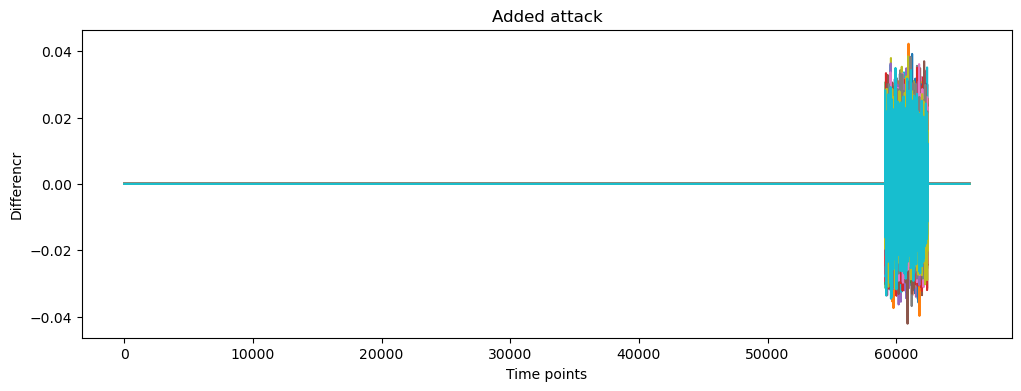

In [21]:
attackStartTime= 59129
attackEndTime= -3285
plt.figure(figsize=(12, 4))# show this, ask to generate 50 instances of attack
differencePfData= (originalPfData3-attackPfData3)[: , :]
plt.plot(differencePfData)
plt.title(f"Added attack")
plt.xlabel("Time points")
plt.ylabel("Differencr")
print(np.std(differencePfData, axis= 0))